# Практическое занятие №1: Базовая классификация

**Задача:** Предсказать, уйдёт ли клиент телеком-компании (отток/churn).  
**Датасет:** `telecom_churn.csv`  
**Модели:** Логистическая регрессия, Дерево решений, KNN

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

## Загрузка и разведочный анализ данных

In [10]:
df = pd.read_csv('telecom_churn.csv')

print("--- Разбор данных ---")
print("Размер датасета (строки, столбцы):", df.shape)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f"Числовые столбцы ({len(numerical_cols)}):", numerical_cols)
print(f"Категориальные столбцы ({len(categorical_cols)}):", categorical_cols)
print("\nПропущенные значения:\n", df.isnull().sum())

print("\nРаспределение целевой переменной (ушел ли клиент):\n", df['churn'].value_counts())

--- Разбор данных ---
Размер датасета (строки, столбцы): (3333, 21)
Числовые столбцы (16): ['account length', 'area code', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls']
Категориальные столбцы (5): ['state', 'phone number', 'international plan', 'voice mail plan', 'churn']

Пропущенные значения:
 state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
t

## Подготовка данных к обучению

In [11]:
X = df.drop('churn', axis=1)
y = df['churn'].astype(int)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

Размер обучающей выборки: 2499 строк
Размер тестовой выборки: 834 строк


## Обучение и проверка моделей

In [12]:
models = {
    'Логистическая регрессия': LogisticRegression(random_state=42, max_iter=1000),
    'Дерево решений': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Точность (Accuracy) модели '{name}': {acc:.4f}")

Точность (Accuracy) модели 'Логистическая регрессия': 0.8597
Точность (Accuracy) модели 'Дерево решений': 0.9508
Точность (Accuracy) модели 'KNN': 0.8837


## Сравнение точности моделей

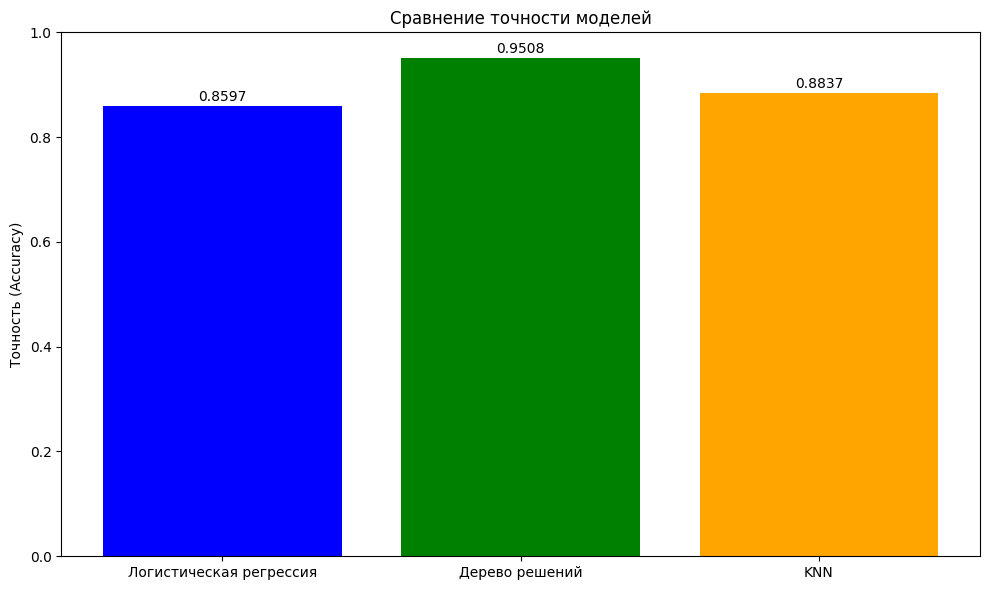

In [13]:
names = list(results.keys())
values = list(results.values())

plt.figure(figsize=(10, 6))
plt.bar(names, values, color=['blue', 'green', 'orange'])
plt.ylabel('Точность (Accuracy)')
plt.title('Сравнение точности моделей')
plt.ylim(0, 1.0)
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.savefig('accuracy_comparison.png')
plt.show()

## Анализ лучшей модели (Confusion Matrix)

Лучшая модель на данном этапе: Дерево решений (Accuracy: 0.9508)



Матрица ошибок (confusion matrix) для лучшей модели:
 [[698  11]
 [ 30  95]]


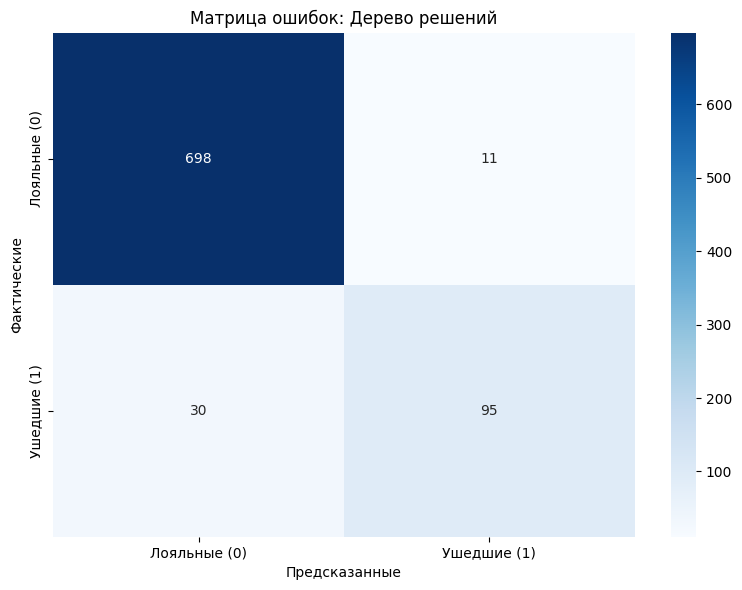


Интерпретация:
Сколько клиентов модель ошибочно предсказала как ушедших: 11
Сколько клиентов модель ошибочно предсказала как лояльных: 30


In [14]:
best_model_name = max(results, key=results.get)
print(f"Лучшая модель на данном этапе: {best_model_name} (Accuracy: {results[best_model_name]:.4f})")

best_model = Pipeline(steps=[('preprocessor', preprocessor),
                             ('classifier', models[best_model_name])])
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
print("\nМатрица ошибок (confusion matrix) для лучшей модели:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Лояльные (0)', 'Ушедшие (1)'], yticklabels=['Лояльные (0)', 'Ушедшие (1)'])
plt.xlabel('Предсказанные')
plt.ylabel('Фактические')
plt.title(f'Матрица ошибок: {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

print(f"\nИнтерпретация:")
print(f"Сколько клиентов модель ошибочно предсказала как ушедших: {false_positives}")
print(f"Сколько клиентов модель ошибочно предсказала как лояльных: {false_negatives}")